# Test `NeuralPDE` notebook

From: [this tutorial example](https://docs.sciml.ai/NeuralPDE/stable/tutorials/pdesystem/)

twnh Jun '25

In [1]:
using NeuralPDE, Lux, Optimization, OptimizationOptimJL, LineSearches, Plots
using ModelingToolkit: Interval

In [2]:
@parameters x y
@variables u(..)
Dxx = Differential(x)^2
Dyy = Differential(y)^2

# 2D PDE
eq = Dxx(u(x, y)) + Dyy(u(x, y)) ~ -sin(pi * x) * sin(pi * y)

# Boundary conditions
bcs = [
    u(0, y) ~ 0.0, u(1, y) ~ 0.0,
    u(x, 0) ~ 0.0, u(x, 1) ~ 0.0
]
# Space and time domains
domains = [x ∈ Interval(0.0, 1.0), y ∈ Interval(0.0, 1.0)]

2-element Vector{Symbolics.VarDomainPairing}:
 Symbolics.VarDomainPairing(x, 0.0 .. 1.0)
 Symbolics.VarDomainPairing(y, 0.0 .. 1.0)

In [3]:
# Neural network
dim = 2 # number of dimensions
chain = Chain(Dense(dim, 16, σ), Dense(16, 16, σ), Dense(16, 1))

# Discretization
discretization = PhysicsInformedNN(
    chain, QuadratureTraining(; batch = 200, abstol = 1e-6, reltol = 1e-6))

@named pde_system = PDESystem(eq, bcs, domains, [x, y], [u(x, y)])
prob = discretize(pde_system, discretization)

#Callback function
callback = function (p, l)
    println("Current loss is: $l")
    return false
end

#11 (generic function with 1 method)

In [4]:
# Optimizer
opt = LBFGS(linesearch = BackTracking())
res = solve(prob, opt, maxiters = 1000)
phi = discretization.phi

NeuralPDE.Phi{StatefulLuxLayer{Static.True, Chain{@NamedTuple{layer_1::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, Nothing, @NamedTuple{layer_1::@NamedTuple{}, layer_2::@NamedTuple{}, layer_3::@NamedTuple{}}}}(StatefulLuxLayer{Static.True, Chain{@NamedTuple{layer_1::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static.True}}, Nothing}, Nothing, @NamedTuple{layer_1::@NamedTuple{}, layer_2::@NamedTuple{}, layer_3::@NamedTuple{}}}(Chain{@NamedTuple{layer_1::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_2::Dense{typeof(σ), Int64, Int64, Nothing, Nothing, Static.True}, layer_3::Dense{typeof(identity), Int64, Int64, Nothing, Nothing, Static

In [5]:
dx = 0.05
xs, ys = [infimum(d.domain):(dx / 10):supremum(d.domain) for d in domains]
analytic_sol_func(x, y) = (sin(pi * x) * sin(pi * y)) / (2pi^2)

u_predict = reshape([first(phi([x, y], res.u)) for x in xs for y in ys],
    (length(xs), length(ys)))
u_real = reshape([analytic_sol_func(x, y) for x in xs for y in ys],
    (length(xs), length(ys)))
diff_u = abs.(u_predict .- u_real)

201×201 Matrix{Float64}:
 0.00357671   0.00340738   0.0032397    …  0.00167391  0.00171265  0.00175163
 0.00350651   0.00334235   0.00317974      0.00166538  0.00170376  0.00174237
 0.00343512   0.00327607   0.00311846      0.00165734  0.00169538  0.00173364
 0.00336263   0.00320862   0.00305594      0.00164977  0.00168749  0.00172542
 0.00328911   0.00314007   0.00299227      0.00164266  0.00168007  0.00171768
 0.00321465   0.00307051   0.00292751   …  0.00163598  0.0016731   0.0017104
 0.00313931   0.003        0.00286174      0.00162972  0.00166655  0.00170357
 0.00306317   0.00292863   0.00279504      0.00162385  0.00166042  0.00169716
 0.00298631   0.00285647   0.00272748      0.00161836  0.00165468  0.00169116
 0.00290881   0.00278359   0.00265914      0.00161323  0.00164931  0.00168554
 ⋮                                      ⋱                          ⋮
 0.000530546  0.000520322  0.000509133     0.002967    0.00305104  0.00313504
 0.000564961  0.000553938  0.000541935     0.0030

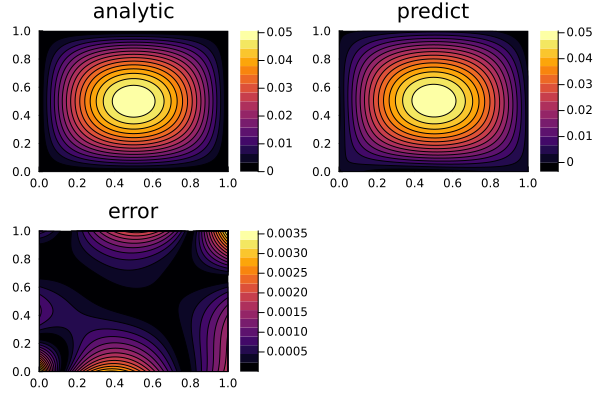

In [6]:
p1 = plot(xs, ys, u_real, linetype = :contourf, title = "analytic");
p2 = plot(xs, ys, u_predict, linetype = :contourf, title = "predict");
p3 = plot(xs, ys, diff_u, linetype = :contourf, title = "error");
plot(p1, p2, p3)